In [47]:
# load the module
%load_ext autoreload
%autoreload 2

import sys 
import os
sys.path.append("../Qtensor")
sys.path.append("../Qtensor/qtree_git")
sys.path.append("../Qtensor/qtree_git/qtree")
sys.path.append("../classical_benchmarks")
sys.path.append("../Experiments/SetCover")
sys.path.append("../../..")
sys.path.append("..")

import json
import copy
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
import pickle
import Generating_Problems as Generator
from gurobi_optimods.qubo import solve_qubo
import qubovert as qv
from qubovert.problems import SetCover as qv_SetCover
import matplotlib
from matplotlib.lines import Line2D

matplotlib.rcParams.update(matplotlib.rcParamsDefault)
 
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/' # for latex, you might need to change this


#print(os.environ['PATH'])# = os.environ['PATH'] + 'c:/Library/TeX/texbin/' # for latex, you might need to change this
label_size = 8
# plt.style.use('fivethirtyeight')
plt.rc("text", usetex=True)
plt.rc("text.latex", preamble=r'\usepackage{dsfont}\usepackage{amsmath}\usepackage{physics}')
#matplotlib.rcParams['text.latex.preamble']=[r'/usepackage{dsfont}/usepackage{amsmath}/usepackage{physics}']
 
pr ={"axes.labelsize": 8,               # LaTeX default is 10pt font.
     'axes.titlesize': 8,               
    "font.size": 8,
    "legend.fontsize": 8,               # Make the legend/label fonts
    "xtick.labelsize": 8,               # a little smaller
    "ytick.labelsize": 8,
    'figure.figsize': (3 * 3.35, 3* 9 * 3.35 / 16), #2.0476
    "errorbar.capsize": 1.5,
    "font.family": "serif",
    "font.serif": [],                   # blank entries should cause plots
    "font.sans-serif": [],    
    }
for k, v in pr.items():
    matplotlib.rcParams[k] = v
   
matplotlib.rcParams["font.family"] = "serif"
# mpl.rcParams["font.serif"] = ["STIX"]
matplotlib.rcParams["mathtext.fontset"] = "stix"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [77]:
with open(f'../data/nodes_{100}_reg_{3}_graph_{0}_opt_Adam_lr_{0.005}_2.pkl', 'rb') as file:
    data = pickle.load(file)   

In [78]:
data


{'graph': 0,
 'analytic_single_p': {'energy': -27.888044324552396,
  'correlations': {frozenset({1}): 0.0,
   frozenset({2}): 0.0,
   frozenset({3}): 0.0,
   frozenset({4}): 0.0,
   frozenset({5}): 0.0,
   frozenset({6}): 0.0,
   frozenset({7}): 0.0,
   frozenset({8}): 0.0,
   frozenset({9}): 0.0,
   frozenset({10}): 0.0,
   frozenset({11}): 0.0,
   frozenset({12}): 0.0,
   frozenset({13}): 0.0,
   frozenset({14}): 0.0,
   frozenset({15}): 0.0,
   frozenset({16}): 0.0,
   frozenset({17}): 0.0,
   frozenset({18}): 0.0,
   frozenset({19}): 0.0,
   frozenset({20}): 0.0,
   frozenset({21}): 0.0,
   frozenset({22}): 0.0,
   frozenset({23}): 0.0,
   frozenset({24}): 0.0,
   frozenset({25}): 0.0,
   frozenset({26}): 0.0,
   frozenset({27}): 0.0,
   frozenset({28}): 0.0,
   frozenset({29}): 0.0,
   frozenset({30}): 0.0,
   frozenset({31}): 0.0,
   frozenset({32}): 0.0,
   frozenset({33}): 0.0,
   frozenset({34}): 0.0,
   frozenset({35}): 0.0,
   frozenset({36}): 0.0,
   frozenset({37}): 0.0,
 

In [58]:
def get_results(optimizer, p, initialization, learning_rate, n):
    graphs=[i for i in range(10)]
    regularity = 3
    energies_list=[]

    for graph in graphs:
        print(n)
        with open(f'../data/nodes_{n}_reg_{regularity}_graph_{graph}_opt_{optimizer}_lr_{learning_rate}.pkl', 'rb') as file:
            data = pickle.load(file)   
        energy = data[initialization][f'p={p}']['energy']
        energies_list.append(energy)    
    
    return np.mean(energies_list), np.std(energies_list)

200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200


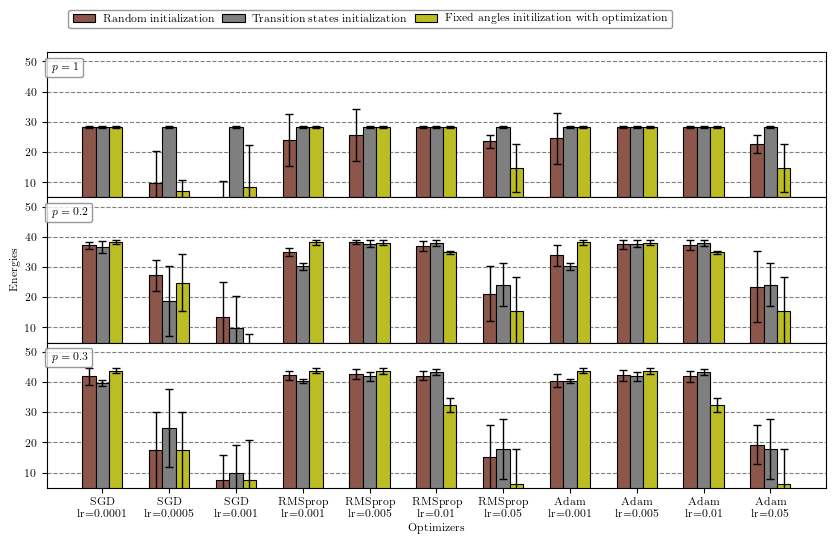

In [59]:
optimizers = ['SGD', 'RMSprop', 'Adam']
ps = [1, 2, 3]
n = 200
initializations = ['random_init', 'transition_states', 'fixed_angles_optimization']

colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink', 'tab:brown', 'tab:grey', 'tab:olive', 'tab:cyan',  'tab:cyan']
width = 0.2
multiplier = 0

fig = plt.figure()
gs = fig.add_gridspec(3, hspace=0)
axs = gs.subplots(sharex=True, sharey=True)

for p in ps:
    multiplier = 0
    data_dic = {f'{name}': [] for name in initializations}
    error_dic = {f'{name}': [] for name in initializations}
    for initialization in initializations:
        labels = []

        for optimizer in optimizers:
                if optimizer == 'SGD':
                    learning_rates = [0.0001, 0.0005, 0.001]
                elif optimizer == 'RMSprop':
                    learning_rates = [0.001, 0.005, 0.01, 0.05]
                elif optimizer == 'Adam':
                    learning_rates = [0.001, 0.005, 0.01, 0.05]

                for learning_rate in learning_rates:
                    mean, error = get_results(optimizer, p, initialization, learning_rate, n)
                    data_dic[str(initialization)].append(-mean)
                    error_dic[str(initialization)].append(error)
                    labels.append(f'{optimizer}\nlr={learning_rate}')
    print(data_dic)
    for attribute, measurement in data_dic.items():
        offset = width * multiplier
        rects = axs[p-1].bar(np.arange(11) + offset, measurement, width, edgecolor = 'black', linewidth=0.8, yerr = error_dic[attribute], error_kw=dict(lw=1, ecolor='black', capthick=1, capsize = 3), color=colors[6+multiplier], alpha=1, label=f'{attribute}', bottom = 0.00001)
        multiplier += 1

for ax in axs:
    ax.label_outer()
    ax.set_xlabel('Optimizers')
    #ax.set_yscale('logit')
    #ax1.gca()
    #ax.yaxis.set_ticklabels([])
    ax.set_ylim(bottom=5., top=53)
    #ax.set_yticks(major_yticks_pos, major_yticks_names)
   # ax.set_yticks(minor_yticks_pos, minor_ticks_names, minor=True)
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed')

axs[1].set_ylabel('Energies', y = 0.5)
axs[2].set_xticks(np.arange(11) + width, labels)

legend_element = [Line2D([0], [0], marker='.', color='w', label='$p = 1$',
                          markerfacecolor='g', markersize=0)]

axs[0].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(-0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=0.2$',
                          markerfacecolor='g', markersize=0)]
axs[1].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(-0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=0.3$',
                          markerfacecolor='g', markersize=0)]
l1 = plt.legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc = 'upper left', fancybox=True, bbox_to_anchor=(-0.01, 1.))
axs[2].add_artist(l1)
plt.legend(labels = ['Random initialization', 'Transition states initialization', 'Fixed angles initilization with optimization'], bbox_to_anchor=(0.415, 3.23), loc = 'center', ncols = 3, edgecolor = 'grey', facecolor='white', columnspacing = 0.7, handletextpad = 0.7)


    
plt.show()